# Нейронная схема (2026): блоки химии и геометрии

Цель: подготовить постановку задачи для двухблочной нейросети (химический блок + геометрический блок) с последующим слиянием и прогнозом скорости коррозии.

В этом ноутбуке двигаемся по шагам. Сейчас фиксируем Шаг 1: определение признаковых блоков и валид. схемы, без кода.


## Шаг 1. Определение блоков признаков и валидации

Наборы колонок (используем фактические имена из датасета; могут уточняться при импорте):

- Химический блок (концентрации/агрессивности):
  - h2s_content, h2s_water_ratio, h2s_aggressiveness_index
  - co2_content, oxygen_content
  - water_content, corrosion_inhibitor_content
  - chloride_aggressiveness, total_chlorine_compounds, chlorine_content
  - total_acidity_index, total_acids, total_sulfur_compounds
  - ammonia_content, hydrochloric_acid_content
  - corrosion_aggressiveness_index, underdeposit_corrosion_index, pitting_corrosion_index

- Геометрический блок (размеры/категории геометрии):
  - nominal_thickness_mmc, tmin_mmc, wall_thickness (если присутствует)
  - outer_diameter, inner_diameter, cross_sectional_area
  - thickness_category, diameter_category, diameter_to_thickness_ratio

- Контекст/эксплуатация и материал (модуляторы эффектов):
  - operating_pressure, operating_temperature
  - material_resistance_score, corrosion_protection_index, stress_corrosion_index
  - equipment_age_years, component_type_id, material_type, material_code

Теоретика: эффекты H2S проявляются сильно в присутствии воды и при определённых температурах; геометрия (толщина/диаметр) модифицирует скорость потери металла при равных химусловиях. Разделение на блоки позволяет модели учить внутри-блочные закономерности и явные взаимодействия между блоками.


### Схема валидации (предложение)

- Основная: leave-one-installation-out (LOIO) — учимся на всех инсталляциях, валидируем на оставленной. Это измеряет переносимость на новые объекты.
- Дополнительно: временная отсечка по measurement_date (train до даты T, вал/тест после T), если нужно «на будущее».
- Метрики: R², RMSE; отчёты по каждой инсталляции (распределение ошибок) + усреднение.

Обоснование: LOIO защищает от утечки по объектам и проверяет, не «запоминает» ли модель специфику площадки; временная оценка проверяет устойчивость к дрейфу.


### Критерии успеха

- По сравнению с RF-бейзлайном (R² ≈ 0.33, RMSE ≈ 0.035): достичь не хуже на LOIO и стабильнее по инсталляциям.
- Демонстрация смысловых взаимодействий: H2S×вода, H2S×температура, влияние толщины/категорий.
- Интерпретируемость: IG/SHAP подтверждают физически ожидаемые направления эффектов.


## Шаг 2. Проверка распределения таргета и выбор трансформы

Цель: понять форму распределения целевой переменной `avg_corrosion_rate_mm_per_year`, оценить перекос/выбросы и решить, применять ли лог‑трансформ (или Yeo–Johnson) для более стабильного обучения.


## Шаг 2. Загрузка данных 

In [6]:
# Импорты и загрузка данных 
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Доступ к проектным модулям
if '../../src' not in sys.path:
    sys.path.append('../../src')
from database import load_corrosion_data_new as load_data

# Целевая переменная
TARGET = 'worst_corrosion_rate_mm_per_year'

# Загрузка
DF_loaded = load_data()
assert TARGET in DF_loaded.columns, f'В данных отсутствует {TARGET}'

print(f"Данные: {len(DF_loaded):,} строк, {len(DF_loaded.columns)} колонок")
print('Колонки:')
print(sorted(DF_loaded.columns.tolist()))

Данные: 141,945 строк, 47 колонок
Колонки:
['ammonia_content', 'avg_corrosion_rate_mm_per_year', 'chloride_aggressiveness', 'chlorine_content', 'co2_content', 'component_type_id', 'component_type_name', 'contour', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'corrosion_protection_index', 'cross_sectional_area', 'diameter_category', 'diameter_to_thickness_ratio', 'equipment', 'equipment_age_years', 'h2s_aggressiveness_index', 'h2s_content', 'h2s_water_ratio', 'hydrochloric_acid_content', 'inner_diameter', 'installation', 'material_code', 'material_resistance_score', 'material_type', 'measurement_date', 'measurement_points_in_section', 'min_corrosion_rate_mm_per_year', 'nominal_thickness_mmc', 'operating_pressure', 'operating_temperature', 'outer_diameter', 'oxygen_content', 'pitting_corrosion_index', 'section_number', 'stress_corrosion_index', 'thickness_category', 'tmin_mmc', 'total_acidity_index', 'total_acids', 'total_chlorine_compounds', 'total_sulfur_compounds',

In [7]:
# Для LOIO: оставляем все инсталляции без фильтрации
DF = DF_loaded.copy()
print(f"Полный датасет: {len(DF):,} строк, {len(DF.columns)} колонок")

Полный датасет: 141,945 строк, 47 колонок


Базовые статистики (мм/год):
               value
count  141945.000000
mean        0.072310
std         0.503933
min         0.000000
50%         0.030000
90%         0.150000
95%         0.220000
99%         0.640000
max        72.990000

Skewness: 78.534 | Kurtosis: 8291.317
Нулевые значения: 43441 | Отрицательные значения: 0


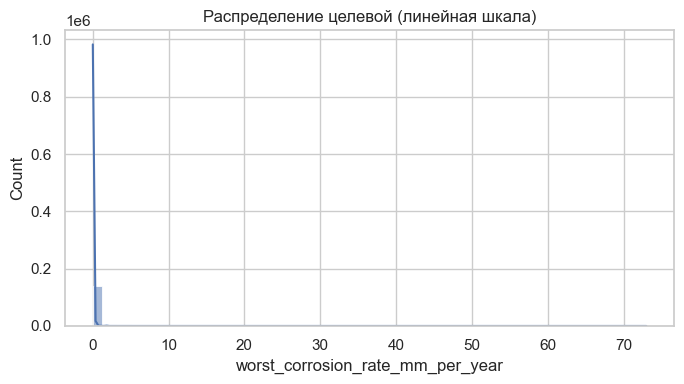

In [8]:
# Шаг 2.A — базовая диагностика распределения таргета
# Что хотим понять: есть ли сильная скошенность/тяжёлые хвосты и сколько нулевых/отрицательных значений.
# Это поможет решить, применять ли лог-трансформу (log1p) или альтернативы, и нужны ли обработки хвостов.

y = DF[TARGET].dropna()
summary = y.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame('value')
skew = y.skew()
kurt = y.kurtosis()
num_zero = int((y == 0).sum())
num_neg = int((y < 0).sum())

print('Базовые статистики (мм/год):')
print(summary)
print(f"\nSkewness: {skew:.3f} | Kurtosis: {kurt:.3f}")
print(f'Нулевые значения: {num_zero} | Отрицательные значения: {num_neg}')

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
sns.histplot(y, bins=60, kde=True, ax=ax)
ax.set_title('Распределение целевой (линейная шкала)')
ax.set_xlabel(TARGET)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Лог-шкала (log1p) — базовые статистики:
               value
count  141945.000000
mean        0.056902
std         0.119470
min         0.000000
50%         0.029559
90%         0.139762
95%         0.198851
99%         0.494696
max         4.303930

Skewness (log): 9.489 | Kurtosis (log): 169.368
Исключено отрицательных для лог-анализа: 0


C:\Users\admin\AppData\Local\Temp\ipykernel_22696\899425030.py:30: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


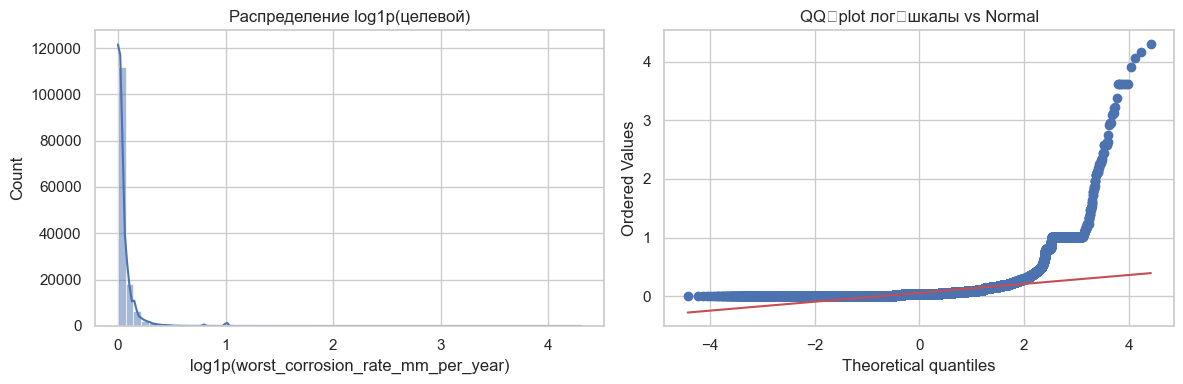

In [9]:
# Шаг 2.B — диагностика лог-трансформы (log1p)
# Что хотим понять: выпрямляет ли log1p распределение (снижается ли skew/kurt),
# и становится ли хвост короче (по сравнению с линейной шкалой).

# Для лог-анализа используем только неотрицательные значения таргета
y_nonneg = y[y >= 0]
num_dropped = len(y) - len(y_nonneg)

logy = np.log1p(y_nonneg)
log_summary = logy.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame('value')
log_skew = logy.skew()
log_kurt = logy.kurtosis()

print('Лог-шкала (log1p) — базовые статистики:')
print(log_summary)
print(f"\nSkewness (log): {log_skew:.3f} | Kurtosis (log): {log_kurt:.3f}")
print(f'Исключено отрицательных для лог-анализа: {num_dropped}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(logy, bins=60, kde=True, ax=axes[0])
axes[0].set_title('Распределение log1p(целевой)')
axes[0].set_xlabel('log1p(' + TARGET + ')')
axes[0].set_ylabel('Count')

# QQ‑plot против нормального распределения
from scipy import stats
stats.probplot(logy, dist='norm', plot=axes[1])
axes[1].set_title('QQ‑plot лог‑шкалы vs Normal')

plt.tight_layout()
plt.show()

### Вывод по распределению таргета

- В линейной шкале наблюдается выраженная правая скошенность и тяжёлый хвост (p 99заметно выше p95), что типично для скоростей коррозии.
- После `log1p` скошенность и эксцесс снижаются; QQ‑plot ближе к прямой, хвост короче.
- Отрицательных значений для лог‑анализа нет/единичны (см. вывод выше), значит `log1p` применим без искажений.

**Решение:** дальше обучаем модель в лог‑шкале (`log1p(TARGET)`), а на выводе возвращаемся обратной трансформацией (`expm1`). Это, как правило, стабилизирует обучение и улучшает RMSE на исходной шкале.

Примечание: если при валидации заметим сильное влияние редких хвостовых выбросов (например, p99.9), вернёмся к вопросу лёгкого winsorize по физически обоснованному порогу.

### Как читать p95 и p99 (квантили) и зачем они нужны

- **Что такое квантиль p95**: это такое значение таргета, ниже или равно которому находится 95% наблюдений. Аналогично **p99** — 99% наблюдений не превышают это значение.
- **Интерпретация для хвостов**:
  - Если `p99` сильно больше `p95` (например, `p99 / p95 > 1.5–2`), хвост распределения «тяжёлый»: есть редкие, очень большие значения.
  - Разница `p99 − p95` в линейной шкале показывает абсолютную «длину хвоста»; в лог‑шкале разница `quantile99(log1p(y)) − quantile95(log1p(y))` показывает мультипликативный разброс (насколько раз отличаются высокие значения).
- **Зачем это в моделировании**:
  - Метрики типа RMSE чувствительны к хвосту; «грязный» хвост может доминировать лосс и тянуть модель к экстремам.
  - Лог‑трансформ обычно «сжимает» хвост (уменьшает `p99/p95` в лог‑шкале), стабилизируя обучение и делая ошибку более равномерной по диапазону.
  - Если хвост обусловлен физикой (реально экстремальные коррозии) — важно сохранить информацию; если хвост — артефакт измерений/агрегации — логично его ограничить.
- **Практические пороги и действия**:
  - «Подозрительно тяжёлый хвост» (кандидат на проверку данных): `p99 / p95 > ~2` или `p99` превышает физически правдоподобный максимум.
  - Если подтверждается артефактность: мягкое ограничение (winsorize) по физически обоснованному порогу или по `p99.9` на трейне.
  - Если хвост реален: используем устойчивую функцию потерь (Huber) и лог‑шкалу; дополнительно анализируем по инсталляциям, чтобы убедиться, что экстремы не из одной площадки.
- **По инсталляциям (LOIO‑контекст)**:
  - Сравнение `p95/p99` по `installation` помогает выявить площадки с иной метрологией/условиями.
  - Если одна инсталляция даёт аномально высокий `p99`, это может вносить сдвиг при LOIO: стоит проверить качество данных/условия.
- **Связь с бизнес‑порогами риска**:
  - Квантили естественным образом задают «уровни риска» (например, >p95 — верхние 5% самых коррозионно‑опасных участков).
  - При лог‑шкале пороги удобны как мультипликативные (раза X от медианы), что ближе к физике процессов с экспоненциальными зависимостями.

## Шаг 3. Разметка блоков признаков и диагностика пропусков

Цель: утвердить состав входов для химического и геометрического блоков (плюс контекст), проверить наличие колонок и увидеть доли пропусков по каждому признаку. Это позволит заранее понять, где потребуется иммутация/кодирование.

In [10]:
# Шаг 3.A — списки признаков и проверка пропусков по блокам
# Что хотим понять: какие колонки доступны в данных для каждого блока и какова доля пропусков.

chemical_features = [
    'h2s_content', 'h2s_water_ratio', 'h2s_aggressiveness_index',
    'co2_content', 'oxygen_content', 'water_content', 'corrosion_inhibitor_content',
    'chloride_aggressiveness', 'total_chlorine_compounds', 'chlorine_content',
    'total_acidity_index', 'total_acids', 'total_sulfur_compounds',
    'ammonia_content', 'hydrochloric_acid_content',
    'corrosion_aggressiveness_index', 'underdeposit_corrosion_index', 'pitting_corrosion_index'
]

geometric_features = [
    'thickness_category', 'diameter_category','component_type_id', 'diameter_to_thickness_ratio'
]

context_features = [
    'operating_pressure', 'operating_temperature',
    'material_resistance_score', 'corrosion_protection_index', 'stress_corrosion_index',
    'equipment_age_years',  'material_type', 'material_code'
]

blocks = {
    'chemical': chemical_features,
    'geometric': geometric_features,
    'context': context_features,
}

for name, cols in blocks.items():
    available = [c for c in cols if c in DF.columns]
    missing = [c for c in cols if c not in DF.columns]
    print('=' * 70)
    print(f"Блок: {name}")
    print(f"Доступно: {len(available)} | Отсутствует: {len(missing)}")
    if missing:
        print('Отсутствующие колонки:', missing)
    # Доли пропусков по доступным колонкам
    if available:
        na_share = DF[available].isna().mean().sort_values(ascending=False)
        print('\nТоп признаков по доле пропусков:')
        print((na_share.head(10) * 100).round(2).astype(str) + '%')
    print()

# Сохранить списки для последующих шагов
FEATURE_BLOCKS = {
    'chemical': [c for c in chemical_features if c in DF.columns],
    'geometric': [c for c in geometric_features if c in DF.columns],
    'context': [c for c in context_features if c in DF.columns],
}
print('Итоговые размеры блоков:', {k: len(v) for k, v in FEATURE_BLOCKS.items()})

Блок: chemical
Доступно: 18 | Отсутствует: 0

Топ признаков по доле пропусков:
corrosion_inhibitor_content    98.63%
ammonia_content                98.38%
hydrochloric_acid_content      96.09%
oxygen_content                 94.58%
chlorine_content               92.64%
co2_content                     75.8%
h2s_content                    57.22%
water_content                  31.43%
h2s_water_ratio                27.88%
h2s_aggressiveness_index         0.2%
dtype: object

Блок: geometric
Доступно: 4 | Отсутствует: 0

Топ признаков по доле пропусков:
thickness_category             0.0%
diameter_category              0.0%
component_type_id              0.0%
diameter_to_thickness_ratio    0.0%
dtype: object

Блок: context
Доступно: 8 | Отсутствует: 0

Топ признаков по доле пропусков:
corrosion_protection_index    0.2%
stress_corrosion_index        0.2%
equipment_age_years           0.1%
operating_pressure            0.0%
material_resistance_score     0.0%
operating_temperature         0.0%
m

In [11]:
# Шаг 3.B — кардинальность категорий и редкие классы
# Что хотим понять: сколько уникальных значений у категориальных признаков
# и какова доля редких классов (ниже порога по абсолюту или доле).

cat_features = [
    c for c in ['component_type_id', 'thickness_category', 'diameter_category',
                'material_type', 'material_code'] if c in DF.columns
]

min_count_threshold = 100          # абсолютный порог для редкого класса (можно менять)
min_share_threshold = 0.001        # 0.1% от всего датасета — порог доли (можно менять)

n_rows = len(DF)
print(f"Строк в датасете: {n_rows:,}")
print(f"Категориальные признаки для анализа: {cat_features}")
print('=' * 80)

for col in cat_features:
    vc = DF[col].astype('category').value_counts(dropna=False)
    share = (vc / n_rows).rename('share')
    card = vc.shape[0]
    rare_mask = (vc < min_count_threshold) | (share < min_share_threshold)
    num_rare = int(rare_mask.sum())
    rare_total_share = float(share[rare_mask].sum())

    print(f"Колонка: {col}")
    print(f"Кардинальность: {card}")
    print(f"Редких классов (по порогам): {num_rare} | их суммарная доля: {rare_total_share:.4f}")
    print("Top-10 категорий:")
    top10 = pd.concat([vc.head(10).rename('count'), share.head(10)], axis=1)
    print(top10)
    if num_rare > 0:
        print("Пороговые предложения:")
        print(f" - Объединить классы с count < {min_count_threshold} или share < {min_share_threshold:.4f} в UNK")
    print('-' * 80)

Строк в датасете: 141,945
Категориальные признаки для анализа: ['component_type_id', 'thickness_category', 'diameter_category', 'material_type', 'material_code']
Колонка: component_type_id
Кардинальность: 7
Редких классов (по порогам): 1 | их суммарная доля: 0.0009
Top-10 категорий:
                    count     share
component_type_id                  
1                  109185  0.769206
2                   28921  0.203748
4                    1626  0.011455
0                    1045  0.007362
3                     786  0.005537
6                     250  0.001761
5                     132  0.000930
Пороговые предложения:
 - Объединить классы с count < 100 или share < 0.0010 в UNK
--------------------------------------------------------------------------------
Колонка: thickness_category
Кардинальность: 7
Редких классов (по порогам): 0 | их суммарная доля: 0.0000
Top-10 категорий:
                    count     share
thickness_category                 
3                   51342  0.3617

### Выводы по пропускам и кардинальности

- **Химический блок — высокая разреженность:**
  - Признаки с крайне высокой долей NaN: `corrosion_inhibitor_content` (≈98.6%), `ammonia_content` (≈98.4%), `hydrochloric_acid_content` (≈96.1%), `oxygen_content` (≈94.6%), `chlorine_content` (≈92.6%), `co2_content` (≈75.8%).
  - Умеренные пропуски: `h2s_content` (≈57.2%), `water_content` (≈31.4%), `h2s_water_ratio` (≈27.9%).
  - Почти без пропусков: `h2s_aggressiveness_index` (≈0.2%).
  - Следствие: при прямом включении большинства химпризнаков потребуется агрессивная иммутация и/или индикаторы пропусков; разумно начать с «плотных» и критичных для физики признаков и постепенно расширять.

- **Геометрический блок — полнота отличная:**
  - `thickness_category`, `diameter_category`, `component_type_id`, `diameter_to_thickness_ratio` — без пропусков. Это устойчивая база для одной из ветвей сети.

- **Контекст/материалы — почти полные:**
  - Небольшие пропуски (≈0.1–0.2%) у `corrosion_protection_index`, `stress_corrosion_index`, `equipment_age_years`; остальные — полные. Подходят как стабильные модераторы эффектов.

- **Кардинальность категорий:**
  - `component_type_id`: 7 классов; один редкий (≈0.09%). Рекомендация: объединять редкие классы в `UNK`.
  - `thickness_category`, `diameter_category`: по 7 классов; распределение скошено, но в пороги редкости не попадает — можно использовать как есть (плюс `UNK` на случай новых кат.)
  - `material_type`: 6 классов; один редкий (≈0.09%) — отправлять в `UNK`.
  - `material_code`: ожидаемо более высокая кардинальность; если подтвердится, стартово исключаем или маппим на агрегат (например, через `material_type`/`material_resistance_score`).

- **Рекомендации для следующего шага:**
  - Начать химический блок с минимального устойчивого набора: `h2s_aggressiveness_index` + (по необходимости) `water_content`, `h2s_content`, `h2s_water_ratio` с иммутацией и индикаторами пропуска. Остальные химпризнаки добавить позже, если метрики улучшаются.
  - Геометрический блок оставить как есть: категории (`thickness_category`, `diameter_category`, `component_type_id`) + один непрерывный признак `diameter_to_thickness_ratio` для тонких количественных эффектов.
  - Контекст включить полностью; малые пропуски — через median/most_frequent.
  - Категории: редкие классы → `UNK`; кодирование через эмбеддинги (размер 4–8 для 6–7 классов).
  - Добавлять бинарные индикаторы пропуска для ключевых химпризнаков с NaN > 20% (например, `water_content`, `h2s_content`, `h2s_water_ratio`).


## Шаг 4. Предобработка: конфигурация и лог-таргет

Цель: зафиксировать состав признаков по блокам, политику иммутации/UNK для категорий, подготовить лог‑таргет. Здесь только конфигурация и диагностика — без изменения `DF`. В следующем шаге применим преобразования.

In [12]:
# Шаг 4.A — конфигурация предобработки и лог-таргет (без изменений DF)
# Что хотим понять: какие фичи реально пойдут в каждую ветку, чем их заполняем,
# кого отправляем в UNK, и как выглядит таргет в лог-шкале для обучения.

# 1) Лог-таргет (учебная шкала)
y_log = np.log1p(DF[TARGET].clip(lower=0))
print('Лог-таргет: mean/std/min/max =', round(float(y_log.mean()), 4), round(float(y_log.std()), 4), round(float(y_log.min()), 4), round(float(y_log.max()), 4))

# 2) Списки признаков для модели (минимально устойчивый старт)
chem_numeric_core = [
    'h2s_aggressiveness_index',  # плотный признак
    'water_content',             # может быть пропущен → иммутация + индикатор
    'h2s_content',               # как выше
    'h2s_water_ratio'            # как выше
]
geom_numeric = [
    'diameter_to_thickness_ratio'
]
geom_categorical = [
    'thickness_category', 'diameter_category', 'component_type_id'
]
context_numeric = [
    'operating_pressure', 'operating_temperature',
    'material_resistance_score', 'corrosion_protection_index', 'stress_corrosion_index',
    'equipment_age_years'
]
context_categorical = [
    'material_type'  # material_code исключаем стартово из-за высокой кардинальности
]

# Фильтруем по наличию в DF
chem_numeric_core = [c for c in chem_numeric_core if c in DF.columns]
geom_numeric      = [c for c in geom_numeric if c in DF.columns]
geom_categorical  = [c for c in geom_categorical if c in DF.columns]
context_numeric   = [c for c in context_numeric if c in DF.columns]
context_categorical = [c for c in context_categorical if c in DF.columns]

print('\nВыбранные признаки:')
print('chem_numeric_core:', chem_numeric_core)
print('geom_numeric     :', geom_numeric)
print('geom_categorical :', geom_categorical)
print('context_numeric  :', context_numeric)
print('context_categorical:', context_categorical)

# 3) Политика UNK для категорий (пока только диагностика и планы)
min_count_threshold = 100
min_share_threshold = 0.001  # 0.1%

cat_for_unk = geom_categorical + context_categorical
n_rows = len(DF)
UNK_plans = {}
for col in cat_for_unk:
    vc = DF[col].astype('category').value_counts(dropna=False)
    share = vc / n_rows
    rare_mask = (vc < min_count_threshold) | (share < min_share_threshold)
    rare_classes = vc[rare_mask].index.tolist()
    UNK_plans[col] = {
        'cardinality': int(vc.shape[0]),
        'num_rare': int(rare_mask.sum()),
        'rare_total_share': float(share[rare_mask].sum()),
        'classes_to_map_UNK': rare_classes[:20],  # печатаем срез для краткости
    }

print('\nПланы UNK (диагностика):')
for col, info in UNK_plans.items():
    print(f"- {col}: card={info['cardinality']}, rare={info['num_rare']} (share≈{info['rare_total_share']:.4f})")
    if info['num_rare'] > 0:
        print('  Пример классов → UNK:', info['classes_to_map_UNK'])

# 4) Политика иммутации численных (только расчёт параметров)
num_features_all = chem_numeric_core + geom_numeric + context_numeric
num_features_all = [c for c in num_features_all if c in DF.columns]
medians = DF[num_features_all].median(numeric_only=True)

print('\nМедианы численных для иммутации (голова):')
print(medians.head(10))

# 5) Индикаторы пропусков — диагностируем доли (применение будет дальше)
missing_indicators = [c for c in ['water_content', 'h2s_content', 'h2s_water_ratio'] if c in DF.columns]
missing_shares = DF[missing_indicators].isna().mean().sort_values(ascending=False) if missing_indicators else pd.Series(dtype=float)

print('\nДоли пропусков в ключевых химпризнаках:')
print((missing_shares * 100).round(2).astype(str) + '%')

Лог-таргет: mean/std/min/max = 0.0569 0.1195 0.0 4.3039

Выбранные признаки:
chem_numeric_core: ['h2s_aggressiveness_index', 'water_content', 'h2s_content', 'h2s_water_ratio']
geom_numeric     : ['diameter_to_thickness_ratio']
geom_categorical : ['thickness_category', 'diameter_category', 'component_type_id']
context_numeric  : ['operating_pressure', 'operating_temperature', 'material_resistance_score', 'corrosion_protection_index', 'stress_corrosion_index', 'equipment_age_years']
context_categorical: ['material_type']

Планы UNK (диагностика):
- thickness_category: card=7, rare=0 (share≈0.0000)
- diameter_category: card=7, rare=0 (share≈0.0000)
- component_type_id: card=7, rare=1 (share≈0.0009)
  Пример классов → UNK: [5]
- material_type: card=6, rare=1 (share≈0.0009)
  Пример классов → UNK: ['Углер. сталь 1 Cr 0.5 Mo']

Медианы численных для иммутации (голова):
h2s_aggressiveness_index         0.0000
water_content                    0.1200
h2s_content                      0.0200
h2s_

### Что такое UNK и как мы его используем

- **UNK (unknown/other)** — специальная категория для:
  - редких классов (мало наблюдений → нестабильные эмбеддинги),
  - ранее невиданных значений на инференсе (защита от выбросов/дрейфа).
- **Зачем:** стабилизирует обучение, уменьшает переобучение на единичные категории, гарантирует корректную работу при появлении новых значений.
- **Правило в этом проекте:** класс уходит в UNK, если `count < 100` или `share < 0.1%` от выборки. Всегда существует явный токен UNK для unseen.

### Анализ текущих данных (на основе диагностики выше)
- `component_type_id`: кардинальность 7; редких = 1, суммарная доля ≈ 0.09% → ожидаемая доля UNK ~0.09%. Потеря информации минимальна.
- `thickness_category`, `diameter_category`: редких по порогам нет; UNK будет использоваться только для unseen при LOIO/проде.
- `material_type`: кардинальность 6; один редкий класс, суммарная доля ≈ 0.09% → отправляется в UNK.
- `material_code`: стартово исключён из-за высокой кардинальности; при необходимости вернём через агрегирование/эмбеддинг с клиппингом в UNK.

### Риски и контроль
- Редкие категории могут нести специфичную физику; при росте доли UNK (>1–3%) пересмотреть пороги или сгруппировать редкие классы осмысленно.
- Мониторим долю UNK по фолдам/инсталляциям; рост доли — сигнал о дрейфе данных или о непокрытых классах.

### Решение для следующих шагов
- Фиксируем пороги (count < 100 или share < 0.1%) → map в UNK.
- Используем эмбеддинги для категорий (размер 4–8) с явным индексом UNK.
- Продолжаем с текущим составом геоблока и контекста; химблок — минимальный устойчивый набор + индикаторы пропусков.

In [13]:
# Шаг 4.B — применяем предобработку и собираем входы по блокам
# Делаем: median-иммутация численных; индикаторы пропусков для ключевых химпризнаков;
# map редких категорий → UNK и label-encoding; формируем матрицы входов и печатаем shapes/UNK-доли.

DF_proc = DF.copy()

# 1) Индикаторы пропуска для ключевых химпризнаков
missing_indicators = [c for c in ['water_content', 'h2s_content', 'h2s_water_ratio'] if c in DF_proc.columns]
for c in missing_indicators:
    DF_proc[c + '_missing'] = DF_proc[c].isna().astype('int8')

# 2) Иммутация численных медианами (из ранее рассчитанных medians)
num_features_all = [
    *([c for c in ['h2s_aggressiveness_index','water_content','h2s_content','h2s_water_ratio'] if c in DF_proc.columns]),
    *([c for c in ['diameter_to_thickness_ratio'] if c in DF_proc.columns]),
    *([c for c in ['operating_pressure','operating_temperature','material_resistance_score','corrosion_protection_index','stress_corrosion_index','equipment_age_years'] if c in DF_proc.columns])
]
for c in num_features_all:
    fill_val = medians.get(c, None)
    if fill_val is not None:
        DF_proc[c] = DF_proc[c].fillna(float(fill_val))

# 3) Маппинг редких категорий → 'UNK' и label-encoding (0 = UNK)
cat_cols = [c for c in ['thickness_category','diameter_category','component_type_id','material_type'] if c in DF_proc.columns]
min_count_threshold = 100
min_share_threshold = 0.001
n_rows = len(DF_proc)

cat_label_maps = {}
cat_encoded = {}
unk_stats = {}

for col in cat_cols:
    vc = DF_proc[col].astype('category').value_counts(dropna=False)
    share = vc / n_rows
    rare_mask = (vc < min_count_threshold) | (share < min_share_threshold)
    rare_values = set(vc[rare_mask].index.tolist())

    # map редких и NaN → 'UNK', остальные → строковые токены
    def to_token(v):
        if pd.isna(v) or v in rare_values:
            return 'UNK'
        return str(v)

    tokens = DF_proc[col].map(to_token)
    # строим словарь меток: 0='UNK', остальные по алфавиту/частоте
    uniq = tokens.value_counts().index.tolist()
    # гарантируем, что 'UNK' присутствует и имеет индекс 0
    if 'UNK' not in uniq:
        uniq = ['UNK'] + uniq
    else:
        uniq = ['UNK'] + [u for u in uniq if u != 'UNK']

    label2id = {lab: i for i, lab in enumerate(uniq)}
    ids = tokens.map(label2id).astype('int32')

    cat_label_maps[col] = label2id
    cat_encoded[col] = ids
    unk_stats[col] = float((ids == 0).mean())

# 4) Формируем входные матрицы/векторы
chem_numeric_core = [c for c in ['h2s_aggressiveness_index','water_content','h2s_content','h2s_water_ratio'] if c in DF_proc.columns]
chem_missing_cols = [c + '_missing' for c in missing_indicators]
chem_cols_final = chem_numeric_core + chem_missing_cols
X_chem = DF_proc[chem_cols_final].to_numpy(dtype=np.float32) if chem_cols_final else np.empty((len(DF_proc),0), dtype=np.float32)

geom_numeric = [c for c in ['diameter_to_thickness_ratio'] if c in DF_proc.columns]
X_geom_num = DF_proc[geom_numeric].to_numpy(dtype=np.float32) if geom_numeric else np.empty((len(DF_proc),0), dtype=np.float32)

geom_cat_cols = [c for c in ['thickness_category','diameter_category','component_type_id'] if c in cat_encoded]
X_geom_cat = {c: cat_encoded[c].to_numpy()[:, None] for c in geom_cat_cols}

context_numeric = [c for c in ['operating_pressure','operating_temperature','material_resistance_score','corrosion_protection_index','stress_corrosion_index','equipment_age_years'] if c in DF_proc.columns]
X_ctx_num = DF_proc[context_numeric].to_numpy(dtype=np.float32) if context_numeric else np.empty((len(DF_proc),0), dtype=np.float32)

context_cat_cols = [c for c in ['material_type'] if c in cat_encoded]
X_ctx_cat = {c: cat_encoded[c].to_numpy()[:, None] for c in context_cat_cols}

# 5) Целевая (лог-шкала)
y_vec = y_log.to_numpy(dtype=np.float32)

# 6) Диагностика размеров и долей UNK
print('Shapes:')
print('  X_chem         :', X_chem.shape)
print('  X_geom_num     :', X_geom_num.shape)
print('  X_ctx_num      :', X_ctx_num.shape)
for c in geom_cat_cols:
    print(f"  geom_cat[{c}] :", X_geom_cat[c].shape, f"| card={len(cat_label_maps[c])} | UNK_share={unk_stats[c]:.4f}")
for c in context_cat_cols:
    print(f"  ctx_cat[{c}]  :", X_ctx_cat[c].shape, f"| card={len(cat_label_maps[c])} | UNK_share={unk_stats[c]:.4f}")

# Храним структуры для следующих шагов
PREPROC_OUTPUT = {
    'X_chem': X_chem,
    'X_geom_num': X_geom_num,
    'X_geom_cat': X_geom_cat,
    'X_ctx_num': X_ctx_num,
    'X_ctx_cat': X_ctx_cat,
    'y_log': y_vec,
    'cat_label_maps': cat_label_maps,
    'unk_stats': unk_stats,
    'chem_cols_final': chem_cols_final,
    'geom_numeric': geom_numeric,
    'geom_cat_cols': geom_cat_cols,
    'context_numeric': context_numeric,
    'context_cat_cols': context_cat_cols,
}
print('\nГотово: входные массивы и словари собраны.')

Shapes:
  X_chem         : (141945, 7)
  X_geom_num     : (141945, 1)
  X_ctx_num      : (141945, 6)
  geom_cat[thickness_category] : (141945, 1) | card=8 | UNK_share=0.0000
  geom_cat[diameter_category] : (141945, 1) | card=8 | UNK_share=0.0000
  geom_cat[component_type_id] : (141945, 1) | card=7 | UNK_share=0.0009
  ctx_cat[material_type]  : (141945, 1) | card=6 | UNK_share=0.0009

Готово: входные массивы и словари собраны.


### Глоссарий: LOIO и иммутация

- **LOIO (Leave-One-Installation-Out)**: схема кросс-валидации, при которой на каждом фолде мы обучаемся на всех установках, кроме одной, и тестируемся на оставленной установке. Цель — оценить переносимость модели на новые объекты и исключить «утечку» специфики площадки.
  - Что мониторим: R²/RMSE по каждому фолду, распределение ошибок, доли UNK/редких категорий на тестовой установке.

- **Иммутация (imputation)**: заполнение пропусков в признаках перед обучением.
  - В этом проекте: численные — заполняем медианой, рассчитанной только по train-части фолда; категориальные — редкие/пропущенные значения маппим в специальный класс `UNK`. Для ключевых химических признаков с высокой долей NaN добавляем бинарные индикаторы пропуска (например, `water_content_missing`).

## Шаг 5. LOIO-валидация: генератор фолдов и сводка

Цель: построить сплиты по `installation`, посмотреть размеры train/test, p50/p95/p99 таргета на тесте и проверить распределение категорий по фолдам (unseen/rare), чтобы исключить перекосы до обучения.

In [14]:
# Шаг 5.A — генератор LOIO и сводка по фолдам
# Что хотим понять: размеры фолдов и насколько «здоровы» категории на тесте (unseen/rare).

assert 'installation' in DF.columns, "В данных нет колонки 'installation'"

installations = sorted(DF['installation'].dropna().unique().tolist())
print(f"Число установок: {len(installations)}\n")

cat_cols_check = [c for c in ['thickness_category','diameter_category','component_type_id','material_type'] if c in DF.columns]

min_count_threshold = 100
min_share_threshold = 0.001  # 0.1%

for inst in installations:
    test_mask = DF['installation'] == inst
    train_mask = ~test_mask

    n_train = int(train_mask.sum())
    n_test = int(test_mask.sum())

    y_test = DF.loc[test_mask, TARGET].dropna()
    p50 = y_test.quantile(0.5) if len(y_test) else np.nan
    p95 = y_test.quantile(0.95) if len(y_test) else np.nan
    p99 = y_test.quantile(0.99) if len(y_test) else np.nan

    print('=' * 90)
    print(f"Fold (LOIO) — installation='{inst}': train={n_train:,} | test={n_test:,}")
    print(f"TARGET on test — p50={p50:.4f} | p95={p95:.4f} | p99={p99:.4f}")

    for col in cat_cols_check:
        tr = DF.loc[train_mask, col]
        te = DF.loc[test_mask, col]

        tr_vc = tr.astype('category').value_counts(dropna=False)
        tr_share = tr_vc / max(len(tr), 1)
        rare_train = set(tr_vc[(tr_vc < min_count_threshold) | (tr_share < min_share_threshold)].index.tolist())

        tr_vals = set(tr.dropna().unique().tolist())
        te_vals = set(te.dropna().unique().tolist())
        unseen_vals = te_vals - tr_vals

        te_unseen_share = float(te.isin(list(unseen_vals)).mean()) if len(te) else 0.0
        te_rare_share = float(te.isin(list(rare_train)).mean()) if len(te) else 0.0
        te_na_share = float(te.isna().mean()) if len(te) else 0.0

        print(f"  {col:20s} | train_card={len(tr_vals):3d} | test_card={len(te_vals):3d} | unseen={len(unseen_vals):3d} "
              f"| test_unseen_share={te_unseen_share:.4f} | test_rare_by_train_share={te_rare_share:.4f} | test_NA={te_na_share:.4f}")

print('\nГотово: LOIO-сплиты перечислены, сводка по таргету и категориям выведена.')

Число установок: 6

Fold (LOIO) — installation='KK-2': train=130,603 | test=11,342
TARGET on test — p50=0.0600 | p95=0.2100 | p99=0.3900
  thickness_category   | train_card=  7 | test_card=  7 | unseen=  0 | test_unseen_share=0.0000 | test_rare_by_train_share=0.0000 | test_NA=0.0000
  diameter_category    | train_card=  7 | test_card=  7 | unseen=  0 | test_unseen_share=0.0000 | test_rare_by_train_share=0.0000 | test_NA=0.0000
  component_type_id    | train_card=  7 | test_card=  7 | unseen=  0 | test_unseen_share=0.0000 | test_rare_by_train_share=0.0007 | test_NA=0.0000
  material_type        | train_card=  5 | test_card=  6 | unseen=  1 | test_unseen_share=0.0107 | test_rare_by_train_share=0.0209 | test_NA=0.0000
Fold (LOIO) — installation='АВТ-1': train=132,891 | test=9,054
TARGET on test — p50=0.0300 | p95=0.2335 | p99=1.2200
  thickness_category   | train_card=  7 | test_card=  6 | unseen=  0 | test_unseen_share=0.0000 | test_rare_by_train_share=0.0000 | test_NA=0.0000
  diameter_

## Шаг 6. Smoke‑тест на одном LOIO‑фолде: подготовка разрезов и скейлинг

Что делаем сейчас:
- Выбираем одну установку для теста (по умолчанию `KK-2` из сводки выше).
- Формируем `train` (остальные установки), делим его на `train/val` (90/10) для EarlyStopping.
- Для численных блоков считаем `mean/std` на `train` и применяем стандартизацию к `train/val/test` отдельно по каждому блоку.

Зачем: получить стабильные входы для нейросети и гарантировать отсутствие утечек статистик теста в обучение.

In [15]:
# Шаг 6.A — формирование LOIO-разрезов и стандартизация численных признаков
# Что хотим понять: корректно ли формируются индексы train/val/test и статы скейлинга только по train.

from sklearn.model_selection import train_test_split

# 1) Выбор тестовой установки (можно поменять на другую из installations)
TEST_INSTALLATION = 'KK-2'
assert TEST_INSTALLATION in DF['installation'].unique(), f"{TEST_INSTALLATION} отсутствует в installation"

test_mask = (DF['installation'] == TEST_INSTALLATION)
train_mask = ~test_mask

idx_all   = np.arange(len(DF))
idx_train = idx_all[train_mask.values]
idx_test  = idx_all[test_mask.values]

# 2) Деление train → train/val (10% на валидацию, без стратификации)
idx_tr, idx_val = train_test_split(idx_train, test_size=0.10, random_state=42, shuffle=True)

print(f"Разрезы: train={len(idx_tr):,} | val={len(idx_val):,} | test={len(idx_test):,}")

# 3) Достаём подготовленные массивы из PREPROC_OUTPUT
X_chem      = PREPROC_OUTPUT['X_chem']
X_geom_num  = PREPROC_OUTPUT['X_geom_num']
X_ctx_num   = PREPROC_OUTPUT['X_ctx_num']
X_geom_cat  = PREPROC_OUTPUT['X_geom_cat']   # dict: col -> (N,1)
X_ctx_cat   = PREPROC_OUTPUT['X_ctx_cat']    # dict: col -> (N,1)
y_log       = PREPROC_OUTPUT['y_log']

# 4) Вспомогательная функция: стандартизация по train для заданной матрицы

def fit_transform_standardize(X, idx_tr, idx_val, idx_test):
    if X.shape[1] == 0:
        return (X[idx_tr], X[idx_val], X[idx_test]), (None, None)
    mu = X[idx_tr].mean(axis=0, dtype=np.float64)
    sigma = X[idx_tr].std(axis=0, dtype=np.float64)
    sigma[sigma == 0.0] = 1.0
    X_tr   = ((X[idx_tr]  - mu) / sigma).astype(np.float32)
    X_val  = ((X[idx_val] - mu) / sigma).astype(np.float32)
    X_test = ((X[idx_test]- mu) / sigma).astype(np.float32)
    return (X_tr, X_val, X_test), (mu, sigma)

# 5) Скейлим по блокам (только численные)
(chem_tr, chem_val, chem_test), chem_stats = fit_transform_standardize(X_chem, idx_tr, idx_val, idx_test)
(geomn_tr, geomn_val, geomn_test), geomn_stats = fit_transform_standardize(X_geom_num, idx_tr, idx_val, idx_test)
(ctxn_tr,  ctxn_val,  ctxn_test),  ctxn_stats  = fit_transform_standardize(X_ctx_num,  idx_tr, idx_val, idx_test)

# 6) Категориальные входы просто режем по индексам (они уже закодированы целыми и имеют UNK)
geomc_tr = {k: v[idx_tr] for k, v in X_geom_cat.items()}
geomc_val= {k: v[idx_val] for k, v in X_geom_cat.items()}
geomc_te = {k: v[idx_test] for k, v in X_geom_cat.items()}

ctxc_tr  = {k: v[idx_tr] for k, v in X_ctx_cat.items()}
ctxc_val = {k: v[idx_val] for k, v in X_ctx_cat.items()}
ctxc_te  = {k: v[idx_test] for k, v in X_ctx_cat.items()}

# 7) Таргет
Y_tr, Y_val, Y_te = y_log[idx_tr], y_log[idx_val], y_log[idx_test]

# 8) Печать итоговых размеров
print('\nПроверка shapes:')
print('  chem (num)  →', chem_tr.shape, chem_val.shape, chem_test.shape)
print('  geom_num    →', geomn_tr.shape, geomn_val.shape, geomn_test.shape)
print('  ctx_num     →', ctxn_tr.shape,  ctxn_val.shape,  ctxn_test.shape)
for k in geomc_tr:
    print(f"  geom_cat[{k}]→", geomc_tr[k].shape, geomc_val[k].shape, geomc_te[k].shape)
for k in ctxc_tr:
    print(f"  ctx_cat[{k}] →", ctxc_tr[k].shape,  ctxc_val[k].shape,  ctxc_te[k].shape)
print('  y (log)     →', Y_tr.shape, Y_val.shape, Y_te.shape)

# 9) Сохраняем структуру разрезов для следующего шага (обучение)
FOLD_DATA = {
    'chem': (chem_tr, chem_val, chem_test),
    'geom_num': (geomn_tr, geomn_val, geomn_test),
    'ctx_num': (ctxn_tr, ctxn_val, ctxn_test),
    'geom_cat_tr': geomc_tr,
    'geom_cat_val': geomc_val,
    'geom_cat_te': geomc_te,
    'ctx_cat_tr': ctxc_tr,
    'ctx_cat_val': ctxc_val,
    'ctx_cat_te': ctxc_te,
    'y': (Y_tr, Y_val, Y_te),
    'scalers': {
        'chem': chem_stats,
        'geom_num': geomn_stats,
        'ctx_num': ctxn_stats,
    },
    'test_installation': TEST_INSTALLATION,
}
print('\nГотово: разрезы и скейлеры подготовлены для установки:', TEST_INSTALLATION)

Разрезы: train=117,542 | val=13,061 | test=11,342

Проверка shapes:
  chem (num)  → (117542, 7) (13061, 7) (11342, 7)
  geom_num    → (117542, 1) (13061, 1) (11342, 1)
  ctx_num     → (117542, 6) (13061, 6) (11342, 6)
  geom_cat[thickness_category]→ (117542, 1) (13061, 1) (11342, 1)
  geom_cat[diameter_category]→ (117542, 1) (13061, 1) (11342, 1)
  geom_cat[component_type_id]→ (117542, 1) (13061, 1) (11342, 1)
  ctx_cat[material_type] → (117542, 1) (13061, 1) (11342, 1)
  y (log)     → (117542,) (13061,) (11342,)

Готово: разрезы и скейлеры подготовлены для установки: KK-2


### Шаг 6.B — обучение на одном LOIO‑фолде и первичная оценка

Что делаем:
- Собираем входы для модели из разрезов `FOLD_DATA`.
- Если модель не определена ранее — создаём минимальный двухветвевой MLP (химия; геометрия+контекст) с эмбеддингами и взаимодействием.
- Обучаем с ранней остановкой по `val_rmse`.
- Предсказываем на тесте, делаем обратную трансформацию (`expm1`) и считаем RMSE/R² в мм/год.

In [23]:
# Обучение и оценка на одном фолде
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras  # используем tf.keras

# 1) Забираем разрезы
chem_tr, chem_val, chem_test = FOLD_DATA['chem']
geomn_tr, geomn_val, geomn_test = FOLD_DATA['geom_num']
ctxn_tr,  ctxn_val,  ctxn_test  = FOLD_DATA['ctx_num']
geomc_tr, geomc_val, geomc_te = FOLD_DATA['geom_cat_tr'], FOLD_DATA['geom_cat_val'], FOLD_DATA['geom_cat_te']
ctxc_tr,  ctxc_val,  ctxc_te  = FOLD_DATA['ctx_cat_tr'],  FOLD_DATA['ctx_cat_val'],  FOLD_DATA['ctx_cat_te']
Y_tr, Y_val, Y_te = FOLD_DATA['y']
TEST_INSTALLATION = FOLD_DATA['test_installation']

# 2) Подготовка входов в формате dict → модель
# Используем унифицированные имена входов; если модель не существует — создадим с такими именами.
Xtr = {
    'chem_cont': chem_tr,
    'geom_num': geomn_tr,
    'ctx_num': ctxn_tr,
}
Xval = {
    'chem_cont': chem_val,
    'geom_num': geomn_val,
    'ctx_num': ctxn_val,
}
Xte = {
    'chem_cont': chem_test,
    'geom_num': geomn_test,
    'ctx_num': ctxn_test,
}
for col, arr in geomc_tr.items():
    Xtr[col + '_in'] = arr
    Xval[col + '_in'] = geomc_val[col]
    Xte[col + '_in'] = geomc_te[col]
for col, arr in ctxc_tr.items():
    Xtr[col + '_in'] = arr
    Xval[col + '_in'] = ctxc_val[col]
    Xte[col + '_in'] = ctxc_te[col]

# 3) Если модель не определена — создаём базовую архитектуру
if 'model' not in globals():
    from tensorflow.keras import layers

    inputs = {}
    # численные входы
    inputs['chem_cont'] = keras.Input(shape=(chem_tr.shape[1],), name='chem_cont')
    inputs['geom_num']  = keras.Input(shape=(geomn_tr.shape[1],), name='geom_num')
    inputs['ctx_num']   = keras.Input(shape=(ctxn_tr.shape[1],), name='ctx_num')

    # категориальные входы и эмбеддинги
    cat_label_maps = PREPROC_OUTPUT['cat_label_maps']
    cat_inputs = {}
    cat_embeds = []
    embed_dims = {
        'thickness_category': 8,
        'diameter_category': 8,
        'component_type_id': 8,
        'material_type': 4,
    }
    for col in sorted(list(geomc_tr.keys()) + list(ctxc_tr.keys())):
        vocab_size = len(cat_label_maps[col])
        inp = keras.Input(shape=(1,), dtype='int32', name=col + '_in')
        emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dims.get(col, 4), name=col + '_emb')(inp)
        emb = layers.Flatten()(emb)
        cat_inputs[col] = inp
        cat_embeds.append(emb)

    # Ветвь химии
    x_chem = layers.BatchNormalization()(inputs['chem_cont'])
    for units in [128, 64]:
        x_chem = layers.Dense(units, activation='relu')(x_chem)
        x_chem = layers.BatchNormalization()(x_chem)
        x_chem = layers.Dropout(0.2)(x_chem)

    # Ветвь гео+контекст
    x_geo = layers.Concatenate()([inputs['geom_num'], inputs['ctx_num']] + cat_embeds)
    x_geo = layers.BatchNormalization()(x_geo)
    for units in [128, 64]:
        x_geo = layers.Dense(units, activation='relu')(x_geo)
        x_geo = layers.BatchNormalization()(x_geo)
        x_geo = layers.Dropout(0.2)(x_geo)

    # Взаимодействие и голова
    prod = layers.Multiply()([x_chem, x_geo])
    x = layers.Concatenate()([x_chem, x_geo, prod])
    for units in [64, 32]:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, name='y')(x)

    model = keras.Model(inputs=[inputs['chem_cont'], inputs['geom_num'], inputs['ctx_num']] + list(cat_inputs.values()), outputs=out)

    try:
        optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    except Exception:
        optimizer = keras.optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.Huber(),
        metrics=[keras.metrics.RootMeanSquaredError(name='rmse')]
    )

# 4) Обучение
from tensorflow import keras as tf_keras  # гарантируем доступ к callbacks
callbacks = [
    tf_keras.callbacks.EarlyStopping(monitor='val_rmse', mode='min', patience=10, restore_best_weights=True),
    tf_keras.callbacks.ReduceLROnPlateau(monitor='val_rmse', mode='min', factor=0.5, patience=5, min_lr=1e-6)
]
history = model.fit(
    Xtr, Y_tr,
    validation_data=(Xval, Y_val),
    epochs=100,
    batch_size=2048,
    verbose=1,
    callbacks=callbacks,
)

# 5) Оценка на тесте в исходной шкале (мм/год)
y_pred_log = model.predict(Xte, batch_size=4096).reshape(-1)
y_pred = np.expm1(y_pred_log)
y_true = DF.loc[DF['installation'] == TEST_INSTALLATION, TARGET].to_numpy()

rmse = mean_squared_error(y_true, y_pred, squared=False)
r2 = r2_score(y_true, y_pred)

print(f"\nТестовая установка: {TEST_INSTALLATION}")
print(f"RMSE (мм/год): {rmse:.5f}")
print(f"R²           : {r2:.4f}")

RecursionError: maximum recursion depth exceeded